In [5]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(gridExtra)
quiet_library(grid)
quiet_library(clusterProfiler)
quiet_library(BaseSet)
quiet_library(jsonlite)
quiet_library(rrvgo)
quiet_library(eulerr)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [6]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [7]:
set.seed(123)

In [8]:
stims <- c("IFNa", "IFNb", "IFN-L1", "IFNg")
celltypes <- c("Bcell", "Tcell", "NK", "Monocyte")
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "B Naive", "B Memory", "Plasma", 
              "NK.CD56hi", "NK.CD56dim", 
              "CD14 Monocyte")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

### 3A. Donor Level IFNa Specific DEGs Heatmap

In [ ]:
donor_degs <- fread(file.path(wd, "DEGs", "Donor_Level_IFNa_IFNg_DEGs_Sup3a.csv"))

In [17]:
stim_select <- "IFNa"

In [18]:
mat <- donor_degs %>% 
        filter(Stim == stim_select) %>%
        mutate(Celltype_Donor = paste(Celltype, Donor, sep = "_")) %>% 
        select(gene, Celltype_Donor, iteration_median_log2FC) %>% 
        pivot_wider(names_from = Celltype_Donor, values_from = iteration_median_log2FC) %>% 
        tibble::column_to_rownames("gene") %>% as.matrix()
mat[is.na(mat)] <- 0

In [19]:
meta <- donor_degs %>% select(Celltype) %>% unique
meta <- data.frame(Celltype = rep(celltypes, each = 5))
HA <- ComplexHeatmap::HeatmapAnnotation(df = meta %>% select(Celltype), 
                                        col = list(Celltype = c("Tcell" = "#00b4d8",
                                                                "Bcell" = "#1b4332",
                                                                "NK" = "#ffbf69",
                                                                "Monocyte" = "#78290f"
                  )))

In [20]:
# IFNa
top_degs <- c("MACROD2", "STAG3", "INPP1", "CPNE5",
            "PGAP1", "RARA", "STIMATE", "UBQLN2", 
            "FASLG", "LPIN2", "FNDC3B", "NFIL3", 
            "CCL8", "MS4A6A", "APOBEC3A", "CTSL")

null device 
          1

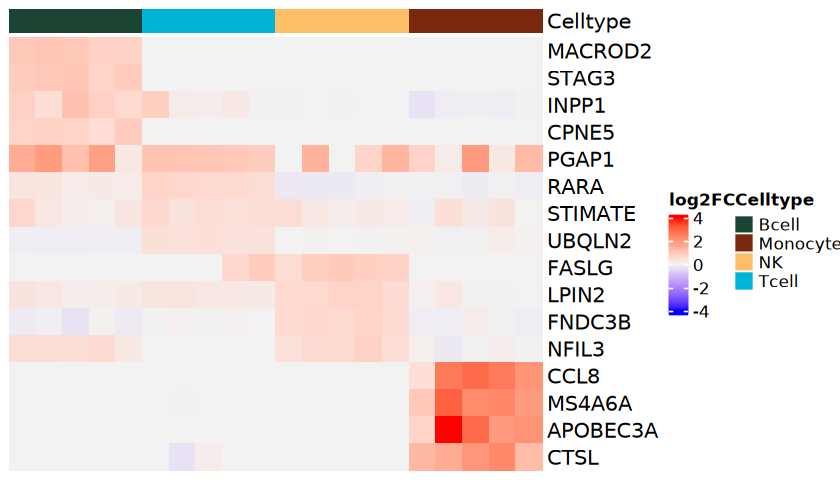

In [21]:
fig.size(4,7)
#pdf(file.path(fig_dir, "Supp", "Sup3", glue("{stim_select}_Unique_Genes_Donor_Heatmap.pdf")), 
#    height = 4, width = 7)
col_fun <- circlize::colorRamp2(c(-4, 0, 4), c("blue", "gray95", "red"))
ComplexHeatmap::Heatmap(mat[top_degs,], name = "log2FC", top_annotation = HA, 
                        show_row_names = T, show_column_names = F, col = col_fun, 
                        #column_split = factor(rep(stims, each = 5), levels = stims),
                        cluster_columns = F, 
                        cluster_column_slices = F, cluster_rows = F,
                        #clustering_distance_rows = "manhattan",
                        column_title_rot = 90
                        ) 
dev.off()

### 3B. IFNa L1 Upset GOBP Pathway Enrichment Heatmap

In [5]:
database <- "GO_BP"
stim <- "IFNa"

In [6]:
# read in GO BP pathways GMT
gs <- getGMT(file.path(wd, "msigdb_v2024.1.Hs", "msigdb_v2024.1.Hs_GMTs", "c5.go.bp.v2024.1.Hs.symbols.gmt"))
select_sets <- data.frame(
            gs_name = gs@relations$sets,
          gene_symbol = gs@relations$elements)

In [7]:
# mapping of gene IDs to symbols
json <- fromJSON(file.path(wd, "msigdb_v2024.1.Hs", "msigdb_v2024.1.Hs_json_files_to_download_locally", "c5.go.bp.v2024.1.Hs.json"), 
                 flatten = TRUE)

df <- do.call(rbind, json) %>% as.data.frame()
df$gs_name <- rownames(df)

select_sets <- select_sets %>% left_join(df)
name_to_id <- select_sets %>% select(gs_name, exactSource) %>% unique()

Joining with `by = join_by(gs_name)`


In [8]:
# load upset dataframe and convert to list
upset_df <- fread(glue(file.path(wd, "DEGs", "Pathways", "{stim}_Upset", "Upset_{stim}_DF.csv")))
res <- split(upset_df$gene, upset_df$set)

In [9]:
# iterate over gene list in each upset plot set
setnames <- names(res)
for (x in seq_along(res)){

    setname <- setnames[[x]]
    print(setname)
    
    # split by up and down-regulated genes
    for (direction in c("Upreg", "Downreg")){
         
        if (direction == "Upreg"){regex = "^\\+"} else {regex = "^\\-"}
        genes_select <- res[[x]][grep(regex, res[[x]])]  %>% sub("^[+-]", "", .)
    
        if (length(genes_select) > 5){
           
            enriched <- enricher(genes_select, TERM2GENE = select_sets)
            
            if (!is.null(enriched)){
                enriched <- enriched@result %>% filter(p.adjust < 0.05)
                
                # formatting 
                if (nrow(enriched) > 2){
                    enriched <- enriched %>% 
                                    left_join(name_to_id, by = c("ID" = "gs_name")) %>%
                                    mutate(ID = as.character(exactSource)) %>%
                                    mutate(Description = as.character(gsub("_", " ", tolower(enriched$Description)))) %>% 
                                    mutate(Description = gsub("gobp ", "", Description)) %>% 
                                    mutate(Description = gsub(" i ", " I ", Description)) %>% 
                                    mutate(Description = gsub(" ii ", " II ", Description))
    
                    # rrvgo reduction of overlapping pathways to parent terms
                    simMatrix <- calculateSimMatrix(enriched$ID,
                                    orgdb="org.Hs.eg.db",
                                    ont="BP",
                                    method="Rel")
                    
                    scores <- setNames(-log10(enriched$qvalue), enriched$ID)
                    reducedTerms <- reduceSimMatrix(simMatrix,
                                                    scores = "size",
                                                    threshold=0.5,
                                                    orgdb="org.Hs.eg.db")
                    
                    enriched %>% 
                        filter(Description %in% reducedTerms$parentTerm) %>% 
                        fwrite(file.path(wd, "DEGs", "Pathways", glue("{stim}_Upset"), database, glue("{setname}_{direction}_Enricher_rrvgo_collapsed_size.csv")))
                }
              }
            }  
        }
    }

[1] "Bcell"
[1] "Bcell_Monocyte"




preparing gene to GO mapping data...

preparing IC data...

'select()' returned 1:many mapping between keys and columns

No scores provided. Falling back to term's GO size



[1] "Bcell_NK"


preparing gene to GO mapping data...

preparing IC data...

'select()' returned 1:many mapping between keys and columns

No scores provided. Falling back to term's GO size



[1] "Bcell_Tcell_NK"


...

preparing gene to GO mapping data...

preparing IC data...

Warning message in calculateSimMatrix(enriched$ID, orgdb = "org.Hs.eg.db", ont = "BP", :
“Removed 2 terms that were not found in orgdb for BP”
'select()' returned 1:many mapping between keys and columns

No scores provided. Falling back to term's GO size



[1] "Monocyte"


preparing gene to GO mapping data...

preparing IC data...

'select()' returned 1:many mapping between keys and columns

No scores provided. Falling back to term's GO size

preparing gene to GO mapping data...

preparing IC data...

'select()' returned 1:many mapping between keys and columns

No scores provided. Falling back to term's GO size



[1] "NK"


preparing gene to GO mapping data...

preparing IC data...

'select()' returned 1:many mapping between keys and columns

No scores provided. Falling back to term's GO size



In [ ]:
# formatting of upset plot set names
setnames_final <- list.files(glue(file.path(wd, "DEGs", "Pathways", "{stim}_Upset", "{database}")), 
                             pattern = "rrvgo_collapsed_size") %>% 
    sub("_Enricher_rrvgo.*", "", .)

sorted_setnames <- setnames_final[grepl("Upreg", setnames_final)]
sorted_setnames <- c(sorted_setnames, setnames_final[grepl("Downreg", setnames_final)])

sorted_setnames

In [ ]:
# get top pathways
pathways_df <- map_dfr(sorted_setnames, function(s){
        pathways <- fread(file.path(wd, "DEGs", "Pathways", glue("{stim}_Upset"), database, glue("{s}_Enricher_rrvgo_collapsed_size.csv"))) 
    
        if (nrow(pathways) > 0){
            pathways$set <- s
            pathways
            }
    })

top_pathways <- pathways_df %>% group_by(set) %>% slice_min(p.adjust, n = 5, with_ties = F) %>% 
    ungroup() %>% pull(Description) %>% unique()
pathways_df_filtered <- pathways_df %>% filter(Description %in% top_pathways) %>% select(set, Description, p.adjust)
sets <- pathways_df_filtered$set %>% unique

In [59]:
# save top five pathways as dataframe 
pathways_df %>% 
    filter(Description %in% top_pathways) %>% 
    fwrite(file.path(wd, "DEGs", "Pathways", glue("{stim}_Upset"), database, glue("{stim}_Upset_Enricher_pathways_top5.csv")))

In [ ]:
# define all possible combinations of Subtype and Stim
all_combinations <- expand.grid(
  set = sets,
  Description = unique(top_pathways)
)


In [ ]:
# add missing combinations and fill missing values with 0
df_complete <- all_combinations %>%
  left_join(pathways_df_filtered, by = c("set", "Description")) %>%
  mutate(p.adjust = ifelse(is.na(p.adjust), 0, p.adjust),
        log_pval = -log10(p.adjust))
df_complete$log_pval[is.infinite(df_complete$log_pval)] <- 0



In [ ]:
df_complete$set <- factor(df_complete$set, levels = sorted_setnames)

null device 
          1

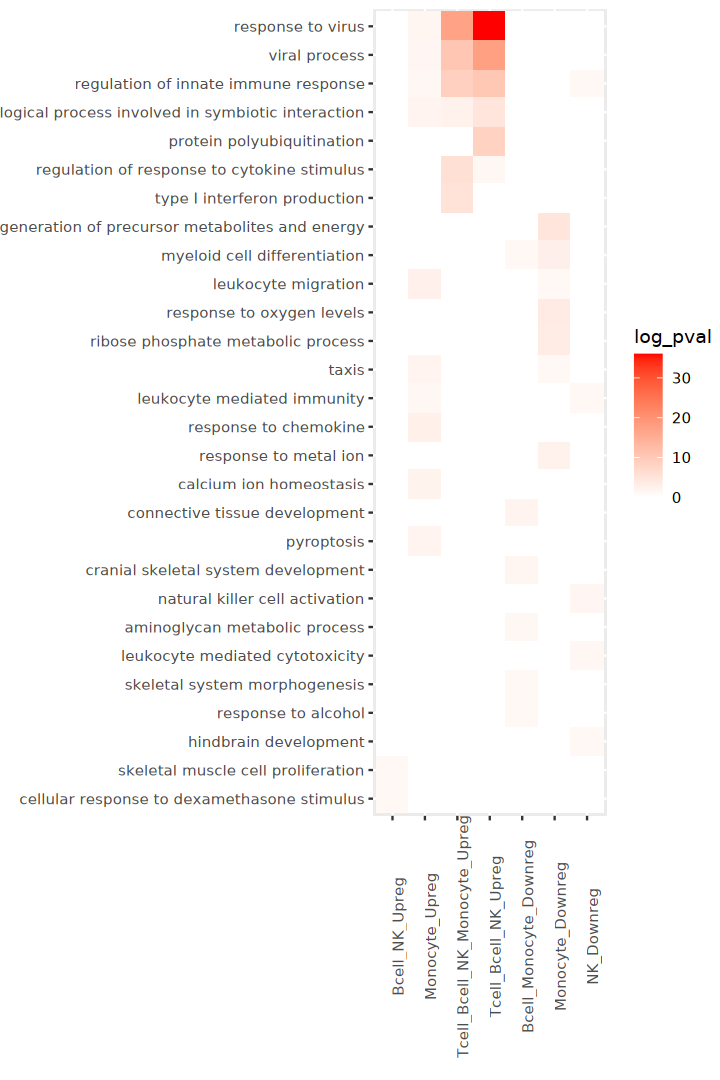

In [82]:
fig.size(9,6)
#pdf(file.path(fig_dir, "Supp", "Sup3", "IFNa_Upset_Plot_GOBP_Heatmap.pdf"), height = 9, width = 6)
ggplot(df_complete, aes(x = set, y = reorder(Description, log_pval), fill = log_pval)) + 
  geom_tile() +
  scale_fill_gradient(low="white", high="red") + 
    theme(axis.text.x = element_text(angle = 90)) + 
    labs(x = "", y = "") 

dev.off()

### 3C. PCA IFNb LogFC

In [83]:
stim_select <- "IFNb"

In [88]:
# pull significant ISGs for select stim
l2_degs <- fread(file.path(wd, "DEGs", "L2_All_Celltypes_Stims_N1_DEGs.csv"))
l2_sig_genes <- l2_degs %>% filter(stim == stim_select & Significant == "Yes") %>% pull(gene) %>% unique()

In [89]:
pca_df <- l2_degs %>% filter(stim == stim_select & gene %in% l2_sig_genes) %>%
    select(gene, median_log2FC, celltype) %>% 
    pivot_wider(names_from = celltype, values_from = median_log2FC) %>% 
    tibble::column_to_rownames("gene")

pca_df[is.na(pca_df)] <- 0

pca_df <- t(pca_df)

In [90]:
# run PCA and format
pca_result <- prcomp(pca_df, scale = T, center = T)  # Scale the data for PCA

pc_scores <- as.data.frame(pca_result$x[, 1:2])

pc_scores$Sample <- rownames(pc_scores)
pc_scores$Stim <- pc_scores$Sample %>% stringr::str_extract("[^_]+$")
pc_scores$Subtype <- pc_scores$Sample %>% stringr::str_extract("[^_]*")

pc_scores$Subtype <- factor(pc_scores$Subtype, levels = subtypes)

null device 
          1

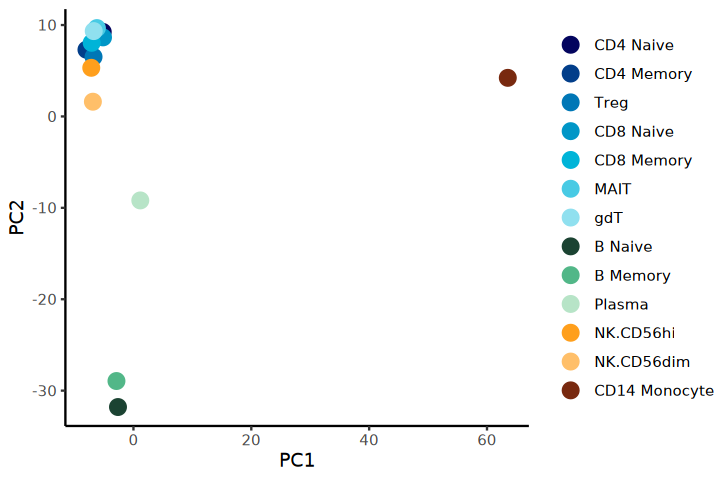

In [91]:
fig.size(4,6)
#pdf(file.path(fig_dir, "Fig2", glue("{stim_select}_PCA_Scatterplot.pdf")), height = 4, width = 6)
ggplot(pc_scores, aes(x = PC1, y = PC2, color = Subtype)) +
    geom_point(size = 4) +
    labs(x = "PC1", y = "PC2") +
    theme_classic() + 
    scale_color_manual(values=subtype_cols) + 
    theme(legend.title = element_blank()) 
dev.off()

### 3D. IFNb DEGs L1 Upset Plot

In [96]:
l1_degs <- fread(file.path(wd, "DEGs", "L1_All_Celltypes_Stims_N1_DEGs.csv"))
l1_degs_select <- l1_degs %>% filter(stim == stim_select & Significant == "Yes")
# separate up and down-reg genes as different features
l1_degs_select$gene_sign <- ifelse(l1_degs_select$median_log2FC > 0, paste0("+", l1_degs_select$gene),
                                                      paste0("-", l1_degs_select$gene))

In [97]:
upset_df <- l1_degs_select %>% 
        select(gene_sign, celltype) %>%
  mutate(value = TRUE) %>%
  distinct() %>%
  pivot_wider(
    names_from = celltype,
    values_from = value,
    values_fill = FALSE
  )

In [98]:
df_mod <- l1_degs_select %>% group_by(gene_sign) %>% summarise(log2FC = mean(median_log2FC)) 
    
upset_df$gene <- gsub("[-a+]", "", upset_df$gene_sign)

upset_df_final <- left_join(upset_df, df_mod[,c("gene_sign", "log2FC")])

Joining with `by = join_by(gene_sign)`


In [99]:
upset_df_final$Direction <- ifelse(upset_df_final$log2FC > 0, "Upreg", "Downreg")
upset_df_final$Direction <- factor(upset_df_final$Direction, levels = c("Upreg", "Downreg"))

In [100]:
# function to convert upset dataframe into list with unique genes per set
get_intersections <- function(upset_df){
  # turn TRUE/FALSE into 1/0 for compatibility
  bin_df <- upset_df %>%
    mutate(across(-gene_sign, as.integer))
  
  # collapse into intersection string
  data_with_intersection <- bin_df %>%
    unite(col = "intersection", -c("gene_sign"), sep = "")
  
  # group genes by intersection pattern
  res <- data_with_intersection %>%
    group_by(intersection) %>%
    summarise(ls = list(gene_sign), .groups = "drop") %>%
    mutate(ls = setNames(ls, intersection)) %>%
    pull(ls)
  
  # name intersections by column names that had "1"
  names(res) <- sapply(names(res), function(x){
    cols <- names(upset_df)[-1]  # exclude gene_sign col
    paste(cols[which(strsplit(x, "")[[1]] == "1")], collapse = "_")
  })
  
  names(res) <- gsub(" ", "_", names(res))
  
  res
}

upset_df[is.na(upset_df)] <- 0
res <- get_intersections(upset_df[,setdiff(names(upset_df), "gene")])

# keep sets with at least 10 genes
res <- res[lengths(res) > 9]

In [103]:
# get top genes per intersection group
upset_df_label <- map_dfr(res, function(r){
    sub_df <- upset_df_final %>% filter(gene_sign %in% r)
    
    if (dim(sub_df)[1] > 200){
        genes_label <- c(slice_max(sub_df, log2FC, n = 1)$gene,
                         slice_min(sub_df, log2FC, n = 1)$gene)
        
        sub_df$label <- ifelse(sub_df$gene %in% genes_label, sub_df$gene, NA)
        
        } else {
        genes_label <- slice_max(sub_df, abs(log2FC), n = 1)$gene
        
        sub_df$label <- ifelse(sub_df$gene %in% genes_label, sub_df$gene, NA)
        }
    sub_df
    })

In [105]:
# set grouping order of intersections on upset
intersection_list <- list(c("Monocyte"),c("Bcell"),c("NK"),c("Tcell"),
                    c("Bcell", "NK"),
                    c("Monocyte", "Bcell"),
                    c("NK", "Tcell"), c("Bcell", "NK", "Tcell"),
                    c("Bcell", "NK", "Tcell", "Monocyte"))

Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message:
“Removed 722 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.ti

null device 
          1

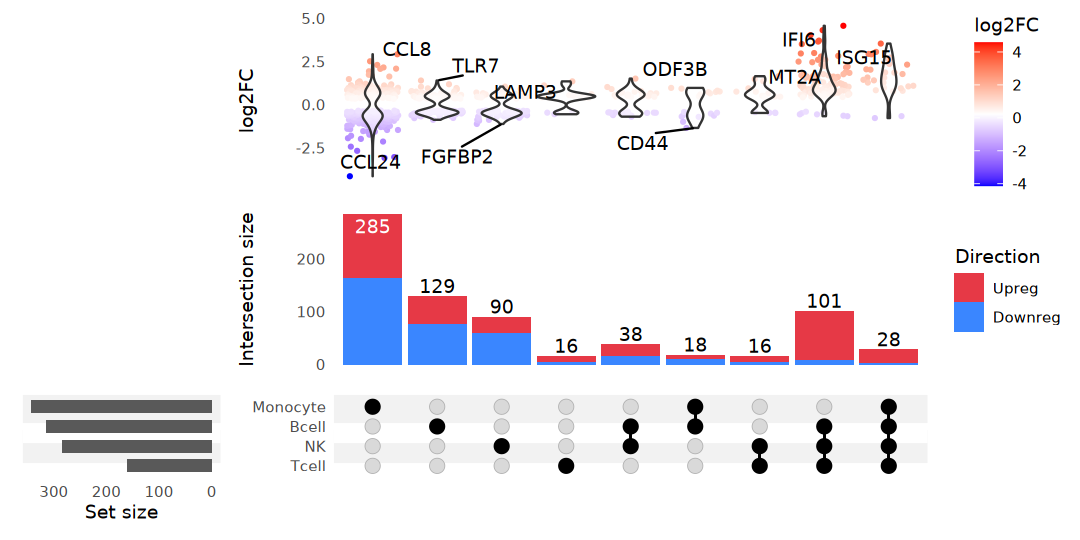

In [111]:
fig.size(4.5,9)
#pdf(file.path(fig_dir, "Supp", "Sup3", glue("{stim}_Upset_Plot.pdf")), height = 4.5, width = 9)
ComplexUpset::upset(
        upset_df_label,
        celltypes,
        intersections=intersection_list,
        sort_intersections=FALSE,
        name = "",
    base_annotations=list(
        'Size'=(
            ComplexUpset::intersection_size(
                mode="exclusive_intersection",
                mapping=aes(fill=Direction),
                size=0,
                text=list(check_overlap=TRUE))+ scale_fill_manual(values=c(
            'Upreg'='#e63946', 'Downreg'='#3a86ff')
            )
        )
    ),
       annotations = list(
    'log2FC'=(
        ggplot(mapping=aes(y=log2FC)) + 
        geom_jitter(aes(color=log2FC), na.rm=T, size = 0.7) + 
        geom_violin(alpha=0.5, na.rm=T, scale = "area") + 
        ggrepel::geom_text_repel(label = upset_df_label$label, force = 100) + 
        scale_color_gradientn(colors = c("blue", "white", "red"))
            )
        ),
        width_ratio = 0.25,
        min_size =10,
        themes=ComplexUpset::upset_default_themes(panel.grid = element_blank())
       
    )
dev.off()

### 3E. Venn Diagram of IFN-L1 Induced Genes in Select Subsets

In [119]:
l2_degs_sig <- l2_degs %>% filter(Significant == "Yes")

In [129]:
subtypes_select <- c("B Naive", "B Memory", "Plasma", "gdT", "CD8 Memory")

ls_degs <- lapply(subtypes_select, function(x){
    l2_degs_sig %>% filter(stim == "IFN-L1" & celltype == x) %>% pull(gene) %>% unique()
    })
names(ls_degs) <- subtypes_select

null device 
          1

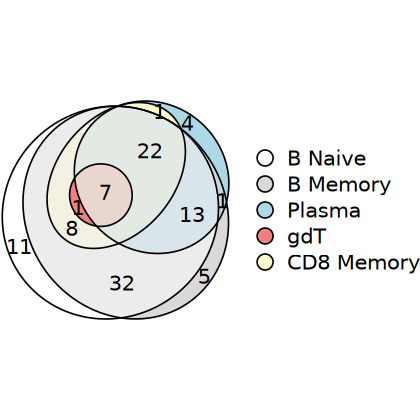

In [130]:
#pdf(file.path(fig_dir, "Supp", "Sup3", "IFN-L1_Venn_Diagram.pdf"), height = 3.5, width = 3.5)
fig.size(3.5,3.5)
plot(euler(ls_degs, shape = "ellipse"), quantities = TRUE, 
     legend = list(labels = subtypes_select))
dev.off()

### 3F. IFNa IFNb Log2FC Violin Plot Comparison

In [112]:
# differentiate IFNa and IFNb exclusive and shared genes
df_final <- map_dfr(celltypes, function(c){
    degs_celltype <- l1_degs %>% filter(celltype == c & stim %in% c("IFNa", "IFNb") & Significant == "Yes")
    #df_celltype <- df %>% filter(subtype == s)

    ifna_genes <- degs_celltype %>% filter(stim == "IFNa") %>% pull(gene)
    ifnb_genes <- degs_celltype %>% filter(stim == "IFNb") %>% pull(gene)

    shared <- intersect(ifna_genes, ifnb_genes)
    ifna_unique <- setdiff(ifna_genes, ifnb_genes)
    ifnb_unique <- setdiff(ifnb_genes, ifna_genes)
    
    degs_celltype$group <- case_when(
      degs_celltype$gene %in% shared ~ "Shared",
      degs_celltype$gene %in% ifna_unique ~ "IFNa_unique",
      degs_celltype$gene %in% ifnb_unique ~ "IFNb_unique"
        )

   degs_celltype
    })

In [115]:
# reformat plotting dataframe
df_final <- df_final %>% 
    pivot_longer(!c(gene, median_pval, Significant, stim, celltype, group), names_to = "Stim", values_to = "logFC") 

Warning message in geom_violin(outlier.size = 0, alpha = 0.5, scale = "width"):
“Ignoring unknown parameters: `outlier.size`”


null device 
          1

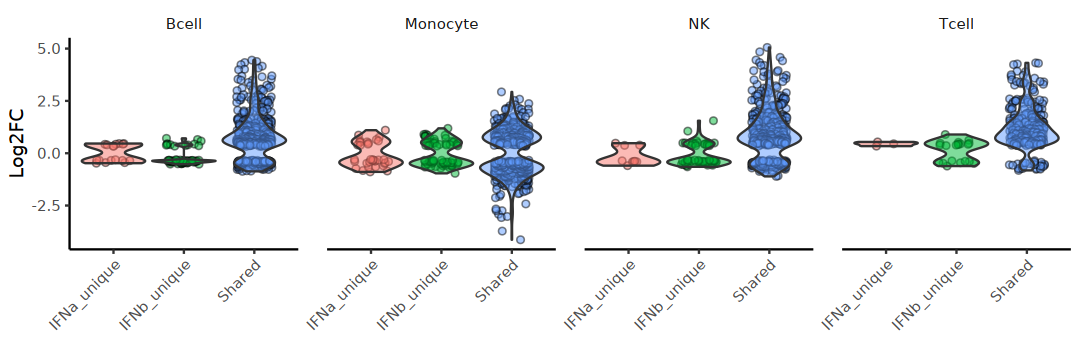

In [118]:
fig.size(3,9)
#pdf(file.path(fig_dir, "Supp", "Sup3", "IFNa_IFNb_Shared_Gene_Violin_Plot.pdf"), height = 3, width = 8)
ggplot(df_final, aes(x=group, y=logFC, fill=group)) + 
    geom_jitter(aes(fill = group), position = position_jitterdodge(jitter.width = 0.5),
                shape = 21, size = 1.5, alpha = 0.5) +
    geom_violin(outlier.size = 0, alpha=0.5, scale = "width")  +
    theme_classic() + theme(axis.text.x = element_text(angle = 90)) + 
    labs(x = "", y = "Log2FC") + 
    facet_wrap(~celltype, ncol = 4) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

dev.off()